# Phase 3.2 — Syndrome extraction & detectors

A surface-code memory runs repeated rounds of stabilizer measurement. Each
measurement is noisy, so we work with **detectors**: a detector is the parity of a
stabilizer between consecutive rounds. In a noiseless run every detector is
deterministically `0`; noise makes some fire. Decoders consume these detection
events, not the raw measurements.

This notebook samples the detector stream from
:class:`qec_project.codes.surface.RotatedSurfaceCode` and sanity-checks its
structure.

In [1]:
import matplotlib.pyplot as plt

from qec_project.codes.surface import RotatedSurfaceCode
from qec_project.noise.circuit import CircuitNoise, depolarizing

code = RotatedSurfaceCode.memory(5)          # d = 5, 5 rounds
noisy = code.circuit(depolarizing(0.005))
clean = code.circuit(CircuitNoise(0, 0, 0, 0))
print(f"d=5: {noisy.num_detectors} detectors over {code.rounds} rounds, "
      f"{noisy.num_observables} logical observable")

d=5: 120 detectors over 5 rounds, 1 logical observable


## Noiseless ⇒ no detections

The defining sanity check: with zero noise, no detector ever fires (and the logical
observable never flips).

In [2]:
det0, obs0 = clean.compile_detector_sampler(seed=0).sample(
    1000, separate_observables=True)
print("clean detections fired:", int(det0.sum()), " logical flips:", int(obs0.sum()))
assert det0.sum() == 0 and obs0.sum() == 0

clean detections fired: 0  logical flips: 0


## The noisy syndrome stream

Under depolarizing noise the detectors fire sparsely and randomly. The mean
detection density per detector is a useful diagnostic; the heat-map shows which
detectors fired across the first few shots.

mean detection density = 0.0691,  logical flip rate (undecoded) = 0.2276


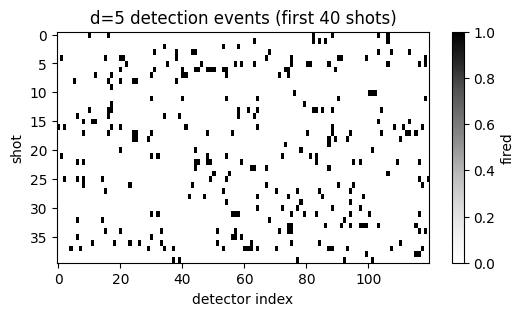

In [3]:
det, obs = noisy.compile_detector_sampler(seed=42).sample(
    20_000, separate_observables=True)
print(f"mean detection density = {det.mean():.4f},  "
      f"logical flip rate (undecoded) = {obs.mean():.4f}")

plt.figure(figsize=(6, 3))
plt.imshow(det[:40], aspect="auto", cmap="Greys", interpolation="nearest")
plt.xlabel("detector index")
plt.ylabel("shot")
plt.title("d=5 detection events (first 40 shots)")
plt.colorbar(label="fired")
plt.show()

## Detection density vs physical error rate

The fraction of detectors that fire scales smoothly with the physical error rate —
the raw signal the decoder must invert in Phase 3.3.

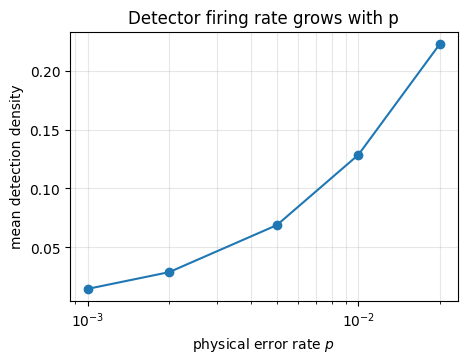

{0.001: np.float64(0.0147), 0.002: np.float64(0.0289), 0.005: np.float64(0.0689), 0.01: np.float64(0.1286), 0.02: np.float64(0.2228)}


In [4]:
ps = [0.001, 0.002, 0.005, 0.01, 0.02]
dens = []
for p in ps:
    d, _ = RotatedSurfaceCode.memory(5).circuit(depolarizing(p)).compile_detector_sampler(
        seed=1).sample(5000, separate_observables=True)
    dens.append(d.mean())
plt.figure(figsize=(5, 3.5))
plt.plot(ps, dens, "o-")
plt.xscale("log")
plt.xlabel("physical error rate $p$")
plt.ylabel("mean detection density")
plt.title("Detector firing rate grows with p")
plt.grid(True, which="both", alpha=0.3)
plt.show()
print(dict(zip(ps, (round(x, 4) for x in dens), strict=False)))

## Recap

* Detectors = inter-round stabilizer parities; noiseless ⇒ all zero (verified).
* Detection density rises smoothly with $p$; the undecoded logical flip rate is
  what MWPM / BP+OSD must suppress.
* **Next (3.3):** feed this detector stream to PyMatching.